In [1]:
#open and read a raw text file
with open("chat_with_Hope.txt", "r", encoding="utf-8") as f:
    lines = f.readlines()

In [2]:
#import library
import pandas as pd
import numpy as np
#for providing loops,iterations
import itertools
#for converting text into number
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, HashingVectorizer
#fpr split training set and test set
from sklearn.model_selection import train_test_split
#for nlp model creation
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.naive_bayes import MultinomialNB
#for sentiment analysis
from nltk.sentiment.vader import SentimentIntensityAnalyzer
#for evaluate perfotmance
from sklearn import metrics
#for creating graphs
import matplotlib.pyplot as plt
#for visualization
import seaborn as sns


In [3]:
df = pd.read_csv("Chat_With_Hope.txt", header=None, engine='python', on_bad_lines='skip')

In [4]:
df 

,0,1,2,3
0,18/09/24,9:10 am - Messages and calls are end-to-end e...,listen to,or share them. *Learn more*
1,18/09/24,10:08 am - Disappearing messages were turned ...,None,None
2,18/09/24,10:08 am - vijai R CUG Hope: Hello,this is Vijai from Hope AI. 😊,None
3,This number is dedicated to helping you with d...,None,None,None
4,Additionally,please use this number,6374442932,for administrative purposes. 📞📝
...,...,...,...,...
4775,07/05/26,11:03 pm - Jazline Sara J,S: Sorry mam by mistake,None
4776,07/05/26,11:04 pm - Jazline Sara J,S: <Media omitted>,None
4777,08/05/26,9:13 am - vijai R CUG Hope: Okok Mam,None,None
4778,08/05/26,9:13 am - vijai R CUG Hope: No issues,None,None


In [5]:
#show no of column 
df.columns

Index([0, 1, 2, 3], dtype='int64')

In [6]:
df['Chat'] = df.iloc[:, 1:].fillna('').astype(str).agg(' '.join, axis=1)

df = df[[0, 'Chat']]

df.columns = ['Date', 'Chat']

df.head()

,Date,Chat
0,18/09/24,9:10 am - Messages and calls are end-to-end e...
1,18/09/24,10:08 am - Disappearing messages were turned ...
2,18/09/24,10:08 am - vijai R CUG Hope: Hello this is V...
3,This number is dedicated to helping you with d...,
4,Additionally,please use this number 6374442932 for admin...


In [7]:
df

,Date,Chat
0,18/09/24,9:10 am - Messages and calls are end-to-end e...
1,18/09/24,10:08 am - Disappearing messages were turned ...
2,18/09/24,10:08 am - vijai R CUG Hope: Hello this is V...
3,This number is dedicated to helping you with d...,
4,Additionally,please use this number 6374442932 for admin...
...,...,...
4775,07/05/26,11:03 pm - Jazline Sara J S: Sorry mam by mis...
4776,07/05/26,11:04 pm - Jazline Sara J S: <Media omitted>
4777,08/05/26,9:13 am - vijai R CUG Hope: Okok Mam
4778,08/05/26,9:13 am - vijai R CUG Hope: No issues


In [8]:
#In this place we have splited chat column into time,name,chat
df=df.drop(0)
df.columns=['Date','Chat']
Message=df["Chat"].str.split("-",n=1,expand=True)
df["Time"]=Message[0]
Message1=Message[1].str.split(":",n=1,expand=True)
df["Name"]=Message1[0]
df["Chat"]=Message1[1]
df=df[["Date","Time","Name","Chat"]]
df

,Date,Time,Name,Chat
1,18/09/24,10:08 am,Disappearing messages were turned off. Change...,None
2,18/09/24,10:08 am,vijai R CUG Hope,Hello this is Vijai from Hope AI. 😊
3,This number is dedicated to helping you with d...,,None,None
4,Additionally,please use this number 6374442932 for admin...,None,None
5,18/09/24,10:36 am,Jazline Sara J S,Ok sir
...,...,...,...,...
4775,07/05/26,11:03 pm,Jazline Sara J S,Sorry mam by mistake
4776,07/05/26,11:04 pm,Jazline Sara J S,<Media omitted>
4777,08/05/26,9:13 am,vijai R CUG Hope,Okok Mam
4778,08/05/26,9:13 am,vijai R CUG Hope,No issues


In [9]:
#Keeps valid data.remove unwanted data in Date column
df = df[df['Date'].astype(str).str.match(r'\d{2}/\d{2}/\d{2}', na=False)]

In [10]:
df

,Date,Time,Name,Chat
1,18/09/24,10:08 am,Disappearing messages were turned off. Change...,None
2,18/09/24,10:08 am,vijai R CUG Hope,Hello this is Vijai from Hope AI. 😊
5,18/09/24,10:36 am,Jazline Sara J S,Ok sir
6,25/09/24,6:15 am,Jazline Sara J S,You deleted this message
7,25/09/24,6:16 am,Jazline Sara J S,<Media omitted>
...,...,...,...,...
4775,07/05/26,11:03 pm,Jazline Sara J S,Sorry mam by mistake
4776,07/05/26,11:04 pm,Jazline Sara J S,<Media omitted>
4777,08/05/26,9:13 am,vijai R CUG Hope,Okok Mam
4778,08/05/26,9:13 am,vijai R CUG Hope,No issues


In [11]:
#check the informatoin about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3737 entries, 1 to 4779
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    3737 non-null   object
 1   Time    3737 non-null   object
 2   Name    3737 non-null   object
 3   Chat    3736 non-null   object
dtypes: object(4)
memory usage: 146.0+ KB


In [12]:
#Library for sentiment analysis
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [13]:
df.index

Index([   1,    2,    5,    6,    7,    8,    9,   10,   11,   12,
       ...
       4761, 4762, 4763, 4773, 4774, 4775, 4776, 4777, 4778, 4779],
      dtype='int64', length=3737)

In [14]:
df.head()

,Date,Time,Name,Chat
1,18/09/24,10:08 am,Disappearing messages were turned off. Change...,None
2,18/09/24,10:08 am,vijai R CUG Hope,Hello this is Vijai from Hope AI. 😊
5,18/09/24,10:36 am,Jazline Sara J S,Ok sir
6,25/09/24,6:15 am,Jazline Sara J S,You deleted this message
7,25/09/24,6:16 am,Jazline Sara J S,<Media omitted>


In [15]:
from IPython.display import HTML, display
display(HTML('<p style="font-size:14px;"><b>SENTIMENT ANALYSIS REPORT</b></p>'))

In [16]:
#In this area we have analyzed the data senimentally
dataset=df
dataset.dropna(inplace=True)
sid = SentimentIntensityAnalyzer()
#It analyze chat and  return sentiment score (for ex neg,pos,neu,compound).
#compound gives overall sentiment score.It combines entire score between -1 to +1. near +1 means very pos,near -1 means very neg, near 0 means neutral
senti = [sid.polarity_scores(chat) for chat in dataset['Chat']]
#senti = sid.polarity_scores(dataset['Chat'][2])
print(senti)

C:\Users\jegat\AppData\Local\Temp\ipykernel_15400\2035495891.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset.dropna(inplace=True)


[{'neg': 0.0, 'neu': 0.674, 'pos': 0.326, 'compound': 0.4404}, {'neg': 0.0, 'neu': 0.312, 'pos': 0.688, 'compound': 0.296}, {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}, {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}, {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}, {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}, {'neg': 0.0, 'neu': 0.312, 'pos': 0.688, 'compound': 0.296}, {'neg': 0.0, 'neu': 0.286, 'pos': 0.714, 'compound': 0.3612}, {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}, {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}, {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}, {'neg': 0.0, 'neu': 0.312, 'pos': 0.688, 'compound': 0.296}, {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}, {'neg': 0.195, 'neu': 0.805, 'pos': 0.0, 'compound': -0.1759}, {'neg': 0.0, 'neu': 0.286, 'pos': 0.714, 'compound': 0.3612}, {'neg': 0.0, 'neu': 0.776, 'pos': 0.224, 'compound': 0.6988}, {'neg': 0.0, 'neu': 0.0, 'pos': 1.0, 'compound': 0.296}, {'neg': 

In [17]:
 def sentimentalAnalysis(data,columnname):
        
        "Importing Necessary Packeage"
        from nltk.sentiment.vader import SentimentIntensityAnalyzer
        sid = SentimentIntensityAnalyzer()
        
        "Deleting null pr empty value"
        data.dropna(inplace=True)
        
        "Checking for a comment"
        #sid.polarity_scores(data[columnname][93])
        
        "Creating respective columns"
        
        data['scores'] = data[columnname].apply(lambda commentText: sid.polarity_scores(commentText))
        data['compound']  = data['scores'].apply(lambda score_dict: score_dict['compound'])
        data['Negtive']  = data['scores'].apply(lambda score_dict: score_dict['neg'])
        data['Postive']  = data['scores'].apply(lambda score_dict: score_dict['pos'])
        data['Neutral']  = data['scores'].apply(lambda score_dict: score_dict['neu'])
        
        "Creating final pos or neg using compound score"
        data['comp_score'] = data['compound'].apply(lambda c: 'pos' if c >=0 else 'neg')
        plt.clf()
        #comp=sns.countplot(x = 'comp_score', hue = 'Name', data = data, palette = 'magma')
        #comp.figure.savefig("date_charts.png")
        "Checking how many pos and neg"
        posneg=pd.DataFrame(data['comp_score'].value_counts())
        return posneg,data
    

In [18]:
#call senimetanalyze fun
pos,data_Senti=sentimentalAnalysis(dataset,columnname='Chat')

C:\Users\jegat\AppData\Local\Temp\ipykernel_15400\3768279434.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.dropna(inplace=True)
C:\Users\jegat\AppData\Local\Temp\ipykernel_15400\3768279434.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['scores'] = data[columnname].apply(lambda commentText: sid.polarity_scores(commentText))
C:\Users\jegat\AppData\Local\Temp\ipykernel_15400\3768279434.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See t

<Figure size 640x480 with 0 Axes>

In [19]:
data_Senti

,Date,Time,Name,Chat,scores,compound,Negtive,Postive,Neutral,comp_score
2,18/09/24,10:08 am,vijai R CUG Hope,Hello this is Vijai from Hope AI. 😊,"{'neg': 0.0, 'neu': 0.674, 'pos': 0.326, 'comp...",0.4404,0.000,0.326,0.674,pos
5,18/09/24,10:36 am,Jazline Sara J S,Ok sir,"{'neg': 0.0, 'neu': 0.312, 'pos': 0.688, 'comp...",0.2960,0.000,0.688,0.312,pos
6,25/09/24,6:15 am,Jazline Sara J S,You deleted this message,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
7,25/09/24,6:16 am,Jazline Sara J S,<Media omitted>,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
8,25/09/24,6:16 am,Jazline Sara J S,<Media omitted>,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
...,...,...,...,...,...,...,...,...,...,...
4775,07/05/26,11:03 pm,Jazline Sara J S,Sorry mam by mistake,"{'neg': 0.649, 'neu': 0.351, 'pos': 0.0, 'comp...",-0.4019,0.649,0.000,0.351,neg
4776,07/05/26,11:04 pm,Jazline Sara J S,<Media omitted>,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
4777,08/05/26,9:13 am,vijai R CUG Hope,Okok Mam,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
4778,08/05/26,9:13 am,vijai R CUG Hope,No issues,"{'neg': 0.688, 'neu': 0.312, 'pos': 0.0, 'comp...",-0.2960,0.688,0.000,0.312,neg


In [20]:
pos

,count
comp_score,
pos,3708
neg,28


In [21]:
#library for preprocessing
from sklearn.feature_extraction.text import TfidfVectorizer

In [22]:
#convert text into number
tfidf=TfidfVectorizer(max_df=0.95,min_df=2,stop_words='english')
dtm=tfidf.fit_transform(df["Chat"])

In [23]:
from IPython.display import HTML, display
display(HTML('<p style="font-size:14px;"><b>TOPIC MODELING REPORT</b></p>'))

In [24]:
#library for topic modeling
#NMF=Non Matrix Factorization
from sklearn.decomposition import NMF
nmf_model=NMF(n_components=5,random_state=42)
nmf_model.fit(dtm)


NMF(n_components=5, random_state=42)

In [25]:
#here n_components=5 means i want 5 topics only
NMF(alpha_W=0.0, alpha_H=0.0,beta_loss='frobenius', init=None, l1_ratio=0.0, max_iter=200,
    n_components=5, random_state=42, shuffle=False, solver='cd', tol=0.0001,
    verbose=0)

NMF(alpha_H=0.0, n_components=5, random_state=42)

In [26]:
for index,topic in enumerate(nmf_model.components_):
    #gives all words in our vocabulary 
    #argsort return index of 10 highest proability elements in ascendind order
    results=([tfidf.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print(results)

['data', 'ipynb', 'blob', 'main', 'salateanciga', 'github', 'com', 'https', 'omitted', 'media']
['doubt', 'shall', 'fine', 'okmam', 'va', 'ma', 'thankyou', 'sir', 'mam', 'ok']
['sure', 'hai', 'welcome', 'okok', 'hi', 'check', 'update', 'yes', 'okay', 'mam']
['hesitate', 'addressed', 'additional', 'lasted', 'trust', 'doing', 'feedback', 'sir', 'mam', 'thank']
['just', 'print', 'good', 'afternoon', 'yes', 'time', 'ur', 'edited', 'deleted', 'message']


In [27]:
#For each chat message, calculate the score for every topic and determine which topic the message belongs to."
topic_results=nmf_model.transform(dtm)
#For each chat message, find the topic with the highest score and save that topic number in a new column called Topic."
df["Topic"]=topic_results.argmax(axis=1)


C:\Users\jegat\AppData\Local\Temp\ipykernel_15400\2775259858.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Topic"]=topic_results.argmax(axis=1)


In [28]:
df

,Date,Time,Name,Chat,scores,compound,Negtive,Postive,Neutral,comp_score,Topic
2,18/09/24,10:08 am,vijai R CUG Hope,Hello this is Vijai from Hope AI. 😊,"{'neg': 0.0, 'neu': 0.674, 'pos': 0.326, 'comp...",0.4404,0.000,0.326,0.674,pos,3
5,18/09/24,10:36 am,Jazline Sara J S,Ok sir,"{'neg': 0.0, 'neu': 0.312, 'pos': 0.688, 'comp...",0.2960,0.000,0.688,0.312,pos,1
6,25/09/24,6:15 am,Jazline Sara J S,You deleted this message,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,4
7,25/09/24,6:16 am,Jazline Sara J S,<Media omitted>,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,0
8,25/09/24,6:16 am,Jazline Sara J S,<Media omitted>,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,0
...,...,...,...,...,...,...,...,...,...,...,...
4775,07/05/26,11:03 pm,Jazline Sara J S,Sorry mam by mistake,"{'neg': 0.649, 'neu': 0.351, 'pos': 0.0, 'comp...",-0.4019,0.649,0.000,0.351,neg,2
4776,07/05/26,11:04 pm,Jazline Sara J S,<Media omitted>,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,0
4777,08/05/26,9:13 am,vijai R CUG Hope,Okok Mam,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,2
4778,08/05/26,9:13 am,vijai R CUG Hope,No issues,"{'neg': 0.688, 'neu': 0.312, 'pos': 0.0, 'comp...",-0.2960,0.688,0.000,0.312,neg,2


In [29]:
df["Topic"].value_counts()

Topic
0    1974
2    1039
1     458
3     175
4      90
Name: count, dtype: int64

In [30]:
dataset=df
# Word Cloud is a visualization that shows the most frequently used words in a text dataset
from wordcloud import WordCloud
#remove common words
from nltk.corpus import stopwords
#nltk = Natural Language Toolkit (a Python library for NLP)
#corpus = collection of text resources provided by NLTK
import nltk
import matplotlib.pyplot as plt
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jegat\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jegat\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


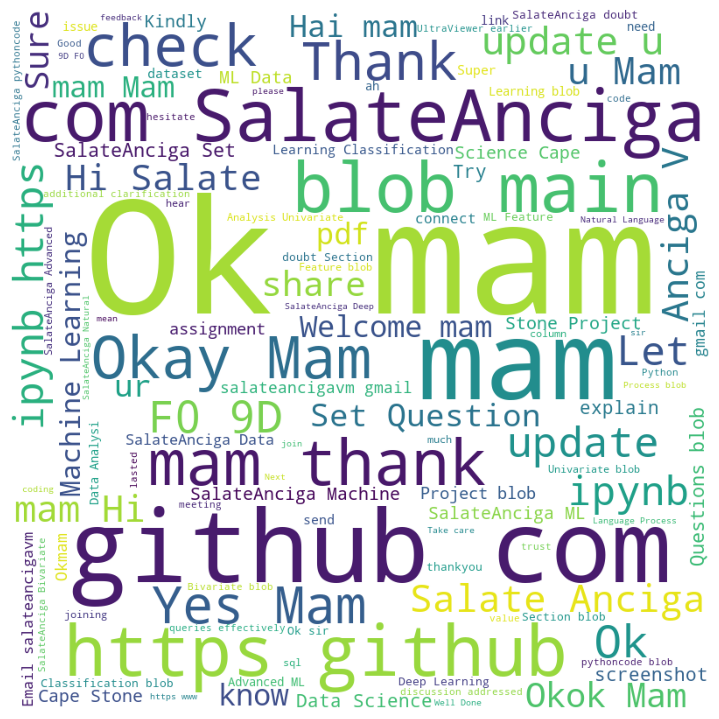

Successfully created


In [31]:
from wordcloud import WordCloud
from nltk.corpus import stopwords
import nltk
import matplotlib.pyplot as plt

nltk.download('stopwords')

# Stop words
stoplist = stopwords.words('english')
stoplist.extend([
    'omitted', 'voice', 'missed', 'call',
    'video', 'deleted', 'media', 'message'
])

# Reset index
dataset = dataset.reset_index(drop=True)

# Combine all chat messages into one string
comment_words = " ".join(dataset['Chat'].astype(str))

# Generate WordCloud
wordcloud = WordCloud(
    width=800,
    height=800,
    background_color='white',
    stopwords=stoplist,
    min_font_size=10
).generate(comment_words)

# Display WordCloud
plt.figure(figsize=(9, 7))
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

print("Successfully created")

In [56]:
from IPython.display import HTML, display
display(HTML('<p style="font-size:14px;"><b>FIND ACTIVE DAY</b></p>'))

In [52]:
print(dataset['Date'].dtype)
dataset['Date']=pd.to_datetime(dataset['Date'])

object


C:\Users\jegat\AppData\Local\Temp\ipykernel_15400\3954553959.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dataset['Date']=pd.to_datetime(dataset['Date'])


In [53]:
dataset['Day'] = dataset['Date'].dt.day_name()

active_day = dataset['Day'].value_counts()

print(active_day)

Day
Wednesday    874
Friday       651
Tuesday      577
Monday       493
Saturday     471
Thursday     448
Sunday       222
Name: count, dtype: int64


<Axes: xlabel='Day'>

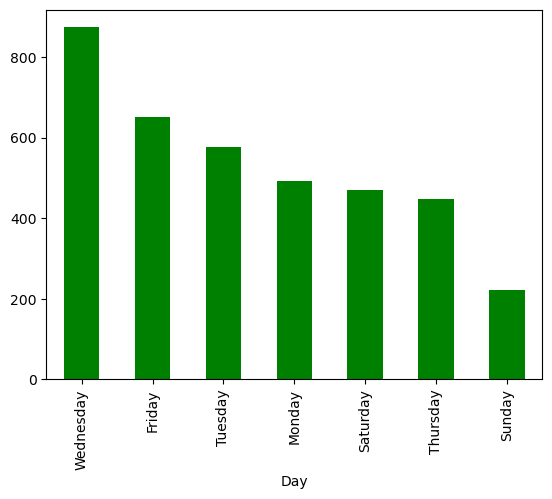

In [60]:
active_day.plot(kind='bar',color='green')

In [70]:
from IPython.display import HTML, display
display(HTML('<p style="font-size:14px;"><b>MOST ACTIVE MONTH</b></p>'))

In [58]:
dataset['Month'] = dataset['Date'].dt.month_name()

month_activity = dataset['Month'].value_counts()

print(month_activity)

Month
April        546
February     414
March        407
November     390
August       317
May          288
July         256
January      253
June         247
October      215
December     210
September    193
Name: count, dtype: int64


<Axes: ylabel='Month'>

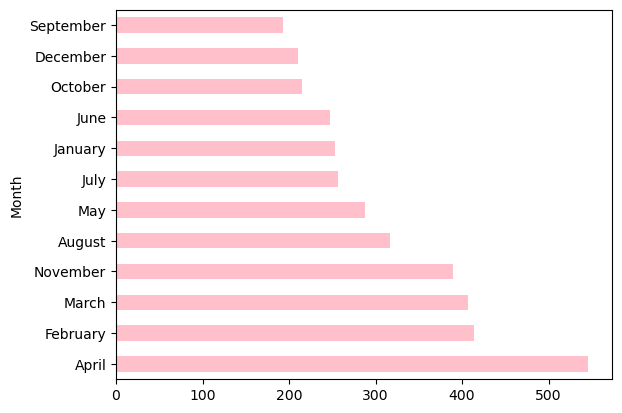

In [61]:
month_activity.plot(kind='barh',color='pink')

In [ ]:
#horizontal line denote number of message sent

In [69]:
from IPython.display import HTML, display
display(HTML('<p style="font-size:14px;"><b>MOST ACTIVE USER</b></p>'))

In [62]:
user_activity = dataset['Name'].value_counts()

print(user_activity)

Name
vijai R CUG Hope    1957
Jazline Sara J S    1779
Name: count, dtype: int64


<Axes: ylabel='count'>

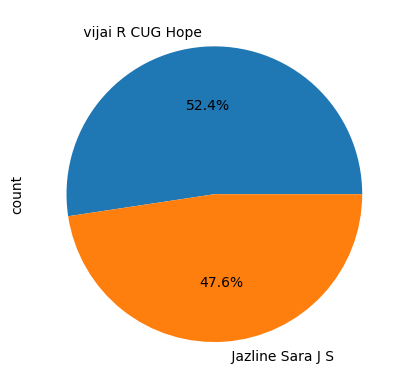

In [66]:
user_activity.plot(kind='pie',autopct='%1.1f%%')

In [32]:
from IPython.display import HTML, display
display(HTML('<p style="font-size:14px;"><b>NLP MODEL CREATION</b></p>'))

In [33]:
#independent Variable
x=dataset["Chat"]
#depedent variable
y=dataset["comp_score"]

In [34]:
#split training set,test set
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=53)

In [35]:
#preprocess the data,convert text into number
#stop_words means remove unnecessary text ex:is,was,of
count_vectorizer = CountVectorizer(stop_words='english')
#Create model and give x_train as a input to given model then predict output
count_train = count_vectorizer.fit_transform(X_train)
print(count_train)
#give x_test as a input to already create model
count_test = count_vectorizer.transform(X_test)

  (0, 310)	1
  (0, 415)	1
  (1, 421)	1
  (1, 474)	1
  (2, 415)	1
  (2, 468)	1
  (3, 717)	1
  (3, 420)	1
  (3, 406)	1
  (5, 421)	1
  (5, 474)	1
  (6, 415)	1
  (6, 470)	1
  (7, 134)	1
  (7, 683)	1
  (8, 468)	1
  (9, 415)	1
  (9, 470)	1
  (10, 415)	1
  (10, 468)	1
  (11, 421)	1
  (11, 474)	1
  (12, 421)	1
  (12, 474)	1
  (13, 324)	1
  :	:
  (2493, 205)	1
  (2493, 427)	1
  (2494, 421)	1
  (2494, 474)	1
  (2495, 415)	1
  (2495, 468)	1
  (2496, 421)	1
  (2496, 474)	1
  (2497, 421)	1
  (2497, 474)	1
  (2498, 223)	1
  (2499, 415)	1
  (2499, 387)	1
  (2499, 665)	1
  (2499, 373)	1
  (2500, 134)	1
  (2500, 688)	1
  (2500, 391)	1
  (2500, 372)	1
  (2500, 412)	1
  (2500, 360)	1
  (2501, 421)	1
  (2501, 474)	1
  (2502, 421)	1
  (2502, 474)	1


In [36]:
#check the length of unique feature
len(count_vectorizer.get_feature_names_out())

728

In [37]:
print(count_train.toarray())

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [40]:
#Values that appear only once in the list of distinct values (no duplicates shown)
print(dataset['comp_score'].unique())

['pos' 'neg']


In [41]:
#call nlp algorithm,MultinominalNavieBays
clf = MultinomialNB()
#create Model
clf.fit(count_train, y_train)
#Make Prediction for test set
pred = clf.predict(count_test)
#Evaluational Metrics 
#check accuracy for actual value and predicted value
score = metrics.accuracy_score(y_test, pred)
print("accuracy:   %0.3f" % score)
#Find confusion matrix
cm = metrics.confusion_matrix(y_test, pred, labels=['pos', 'neg'])

accuracy:   0.989


In [42]:
from sklearn.metrics import classification_report
#Make Classification report.This problem comes under ML-Classification
report=classification_report(y_test, pred)

In [43]:
print(report)

              precision    recall  f1-score   support

         neg       0.00      0.00      0.00         8
         pos       0.99      1.00      0.99      1225

    accuracy                           0.99      1233
   macro avg       0.50      0.50      0.50      1233
weighted avg       0.99      0.99      0.99      1233



In [44]:
dataset["Chat"][2]

' You deleted this message '

In [45]:
#select 2nd row from count_train(preprocess training set)
count_train[[2]]

<1x728 sparse matrix of type '<class 'numpy.int64'>'
	with 2 stored elements in Compressed Sparse Row format>

In [46]:
#learn all unigue words
count_vectorizer = CountVectorizer(stop_words='english')
#convert text into number
count_train = count_vectorizer.fit_transform(X_train)

In [47]:
#count_input=count_vectorizer.transform([[dataset["text"][0]]])
#view original data
X_train[[2]]

2     You deleted this message 
Name: Chat, dtype: object

In [48]:
#predict the chat pos or neg
clf.predict(count_train[[2]])

array(['pos'], dtype='<U3')